In [206]:
#Import statements

from data_utils import load_dataset
import data_utils
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats
from scipy import linalg

%matplotlib inline

np.random.seed(5)

In [207]:
#Helper functions used for question 1a

#This function calculates the sigmoid given an input
def sig(z):
    return 1.0/(1+np.exp(-z))

#This function calculates the log likelihood given the weights, the x data, and y data, and sigma as input
def log_likelihood(w,x,y,sigma=1.0):
    f = sig(np.dot(x,w)) #Calculates f
    return np.sum(y*np.log(f+1e-9)+(1-y)*np.log(1-f+1e-9))

#This function calculates the log likelihood gradient given the weights, the x data, and y data, and sigma as input
def log_likelihood_grad(w,x,y,sigma=1.0):
    f = sig(np.dot(x,w))
    return np.sum(np.multiply((y-f),x),axis=0).reshape(-1,1)

#This function calculates the log prior given the weights and sigma as input
def log_prior(w,sigma=1.0):
    return (-(w.shape[0]/2)*np.log(2*np.pi)-(w.shape[0]/2)*np.log(sigma**2) 
            - np.squeeze(np.sum((np.square(w)/(2*sigma**2)),axis=0)))

#This function calculates the log prior gradient given the weights and sigma as input
def log_prior_grad(w,sigma=1.0):
    return -w/sigma**2
    
#This function calculates the loss given the weights, the x data, and y data, and sigma as input
def loss_func(w,x,y,sigma=1.0):
    return -log_likelihood(w,x,y,sigma)-log_prior(w,sigma)

#This function calculates the gradient for full batch gradient descent given the weights, the x data, y data and sigma as input
def GD_grad(w,x,y,sigma=1.0):
    return -log_likelihood_grad(w,x,y,sigma)-log_prior_grad(w,sigma)

#This function calculates the Hessian used in the Laplace approximation given the weights, the x data, y data and sigma as input
def Hessian(w,x,y,sigma=1.0):
    f = sig(np.dot(x,w))
    return np.matmul(x.T,f*(f-1)*x) - (1/(sigma**2))*np.eye(w.shape[0])

In [208]:
#Helper functions used for Question 1b

#This function calculates the likelihood given the weights, the x data, and y data, and sigma as input
def likelihood(w,x,y,sigma=1.0):
    return np.exp(log_likelihood(w,x,y,sigma))

#This function calculates the prior given the weights and sigma as input
def prior(w,sigma=1.0):
    return log_prior(w,sigma)

#This function calculates the propasal given the weights, mean/MAP estimate, and sigma as input
def proposal(w,prop_sigma,mean):
    return np.prod((1/(2*np.pi*prop_sigma**2)**(1/2))*np.exp(-np.square(mean-w)/(2*prop_sigma**2)))

#This function calculates the function r(w) used for importance sampling given the weights,the x data, and y data, the proposal
#std deviation, the mean/MAP estimate, and the prior std deviation as input
def r(w,x,y,prop_sigma,mean,sigma=1.0):
    return likelihood(w,x,y,sigma)*prior(w,sigma)/proposal(w,prop_sigma,mean)

#This function returns a sample from the proposal distribution given the mean/MAP estimate and the proposal std deviation
def proposal_distribution(mean,prop_sigma):
    return stats.multivariate_normal.rvs(mean=mean.reshape(-1,), cov=np.eye(np.shape(mean.reshape(-1,))[0])*(prop_sigma**2))

#The function returns a list of weights that were sampled from the proposal distribution given a sample size, mean/MAP estimate,
#and the proposal std deviation
def sample_weights(sample_size,mean,prop_sigma):
    w = []
    for i in range(sample_size):
        w.append(proposal_distribution(mean,prop_sigma))
    return w

#This function computes the log likelihood of a prediction given a list of predictions and a list of actual results
def compute_log_likelihood(y_pred,y):
    return np.squeeze(np.dot(y.T,np.log(y_pred))+np.dot(np.subtract(1,y).T, np.log(np.subtract(1,y_pred))))

#This function computes the accuracy of a prediction given a list of predictions and a list of actual results
def compute_accuracy(y_actual, y_predict):
    y_predict = np.squeeze(y_predict)
    return (y_predict == y_actual).sum() / len(y_actual)

In [209]:
#Question 1

#MAP Estimate

#This function calculates the MAP_estimate for the weights given a learning rate, sigma, and an error threshold where gradient
#descent is performed until all gradient values are below the error threshold.

def MAP_estimate(lr,sigma,error_threshold):
    
    #Load dataset and perform data processing
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
    y_train, y_valid, y_test = y_train[:,1,None], y_valid[:,1,None], y_test[:,1,None]
    
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    #Record dataset parameters
    N_train = len(x_train)
    N_test = len(x_test)
    
    #Add ones as bias
    train_bias = np.ones((N_train,1))
    x_train = np.hstack([train_bias, x_train])
    test_bias = np.ones((N_test,1))
    x_test = np.hstack([test_bias, x_test])

    D = len(x_train[0])
    
    #Initialize variables
    lowest_loss = float('inf')
    GD_best_w = None
    w = np.zeros((D,1))
    i = 0
    grad = 1
    
    #Perform full batch gradient descent until all gradient values become smaller than the error threshold
    while np.amax(grad)>error_threshold:
        i+=1
        #Calculate gradient
        grad = GD_grad(w,x_train,y_train,sigma)
        
        #Update weights
        w = w - grad*lr
        
        #Calculate loss
        loss = loss_func(w,x_train,y_train,sigma)
        
        #If loss is lower than the current loss, record the values of the weights
        if loss < lowest_loss:
            GD_best_w = w
            lowest_loss = loss
    
    return GD_best_w

In [210]:
#This function calculates the marginal likelihood given the weights at the MAP estimate and sigma
def marginal_likelihood(w_star,sigma):
    
    #Load dataset and perform data processing
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
    y_train, y_valid, y_test = y_train[:,1,None], y_valid[:,1,None], y_test[:,1,None]
    
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    #Record dataset parameters
    N_train = len(x_train)
    N_test = len(x_test)
    
    #Add ones as bias
    train_bias = np.ones((N_train,1))
    x_train = np.hstack([train_bias, x_train])
    test_bias = np.ones((N_test,1))
    x_test = np.hstack([test_bias, x_test])

    D = len(x_train[0])
    
    #Calculate marginal likelihood
    ll = log_likelihood(w_star,x_train,y_train,sigma)
    lp = log_prior(w_star,sigma)
    H = Hessian(w_star,x_train,y_train,sigma)
    
    marginal = ll + lp - (-((D-1)/2)*np.log(2*np.pi) + (1/2)*np.log(-np.linalg.det(H)))
    
    return marginal

In [211]:
#This function prints out marginal likelihoods in a list given a learning rate, a list of prior variances and an error
#threshold where gradient descent terminates once all gradient values are below the threshold.

def Question_1_a(lr, variances, loss_terminate):
    
    marginals = []
    for var in variances:
        sigma = var**(1/2)
        w_star = MAP_estimate(lr,sigma,loss_terminate)
        marginal = marginal_likelihood(w_star,sigma)
        marginals += [marginal]
        
    print(marginals)
    
    return

In [212]:
#This function generates the optimal number of importance weights and the optimal variance for the proposal distribution
#given the iris dataset, the mean/MAP estimate for the weights, a list of number of importance weight and a list of
#variances for the proposal distribution.

def importance_sampling_parameters(x_train, x_valid, y_train, y_valid, mean, sample_sizes, sample_vars):
    
    #Record dataset parameters
    N_train = len(x_train)
    N_valid = len(x_valid)

    #Add ones as bias
    train_bias = np.ones((N_train,1))
    x_train = np.hstack([train_bias, x_train])
    
    valid_bias = np.ones((N_valid,1))
    x_valid = np.hstack([valid_bias, x_valid])

    D = len(x_test[0])
    
    #Use a prior variance of 1
    sigma = 1
    prop_vars = list(sample_vars)

    #Record the best log likelihood
    best_ll = -np.inf
    opt_prop_sigma = None
    opt_sample_size = None
    
    #Loop through list of sample sizes to find the best sample size
    for sample_size in sample_sizes:
        
        #Loop through list of sample variances to find the best sample variance for the proposal distribution
        for prop_var in sample_vars:
                  
            prop_sigma = prop_var**(1/2)
                  
            #Record validation predictions
            valid_pred = np.zeros(N_valid)
            valid_class = np.zeros(N_valid)

            #Get list of sample weights
            w = sample_weights(sample_size, mean, prop_sigma)
            
            #Use validation set to find optimal variance for the proposal distribution
            #by computing the predictive posterior for all data points in the validation set
            
            for N in range(N_valid):
                
                #Sum over all values of r(w) for all importance sampling weights
                r_sum = 0
                for i in range(sample_size):
                    #Calculate r(w)
                    r_sum += r(w[i].reshape(-1,1), x_train, y_train, prop_sigma, mean, sigma)
                
                #Loop through all importance sampling weights
                pred_sum = 0
                for i in range(sample_size):
                    
                    #Get validation prediction contribution for a single set of weights using sigmoid for logistic regression
                    y_star = sig(np.dot(x_valid[N], w[i].reshape(-1,1)))
                    
                    #Add to prediction sum and normalize
                    pred_sum += y_star*r(w[i].reshape(-1,1), x_train, y_train, prop_sigma, mean, sigma)/r_sum
                
                
                #Get numerical prediction for validation point
                valid_pred[N] = pred_sum
                
                #Get class prediction for validation point
                if pred_sum < 0.5:
                    valid_class[N] = 0
                elif pred_sum > 0.5:
                    valid_class[N] = 1
                else:
                    valid_class[N] = -1
            
            #Store optimal hyperparameters including sample size and proposal variance
            valid_ll = compute_log_likelihood(valid_pred, y_valid)
            if valid_ll > best_ll:
                best_ll = valid_ll
                best_accuracy = compute_accuracy(valid_class, y_valid)
                opt_prop_sigma = prop_sigma
                opt_sample_size = sample_size
    
    #Print out optimal variance and optimal number of importance weights and their log-likelihood and accuracy
    print("Optimal Variance: " + str(int(opt_prop_sigma**2)))
    print("Optimal Number of Importance Weights: " + str(opt_sample_size))
    print("Best Log-Likelihood: " + str(best_ll))
    print("Best Accuracy: " + str(best_accuracy))
    
    return opt_prop_sigma, opt_sample_size, best_ll, best_accuracy

In [213]:
#This function generates predictions on the test set give the iris dataset, the mean/MAP estimate, the optimal number of
#importance weights and the optimal variance for the proposal distribution.

def importance_sampling_test(x_train, x_valid, x_test, y_train, y_valid, y_test, mean, opt_sample_size, opt_prop_sigma):
    
    #Perform data processing
    x_train = np.vstack((x_train, x_valid))
    y_train = np.vstack((y_train, y_valid))

    #Record dataset parameters
    N_train = len(x_train)
    N_test = len(x_test)
    
    #Add ones as bias
    train_bias = np.ones((N_train,1))
    x_train = np.hstack([train_bias, x_train])
    
    test_bias = np.ones((N_test,1))
    x_test = np.hstack([test_bias, x_test])
    
    #USe prior variance of 1
    sigma = 1

    #Record test predictions
    test_pred = np.zeros(N_test)
    test_class = np.zeros(N_test)

    #Sample S number of weights as found during validation and optimization of hyperparameters
    w = sample_weights(opt_sample_size, mean, opt_prop_sigma)

    #Find predictions for the entire test set
    for N in range(N_test):

        #Sum over all values of r(w) for all importance sampling weights
        r_sum = 0
        for i in range(opt_sample_size):
            #Calculate r(w)
            r_sum += r(w[i].reshape(-1,1), x_train, y_train, opt_prop_sigma, mean, sigma)

        #Loop through all importance sampling weights
        pred_sum = 0
        for i in range(opt_sample_size):
            #Get validation prediction contribution for a single set of weights using sigmoid for logistic regression
            y_star = sig(np.dot(x_test[N], w[i].reshape(-1,1)))
            #Add to prediction sum and normalize
            pred_sum += y_star*r(w[i].reshape(-1,1), x_train, y_train, opt_prop_sigma, mean, sigma)/r_sum

       
        #Get numerical prediction for test point
        test_pred[N] = pred_sum
        
        #Get class prediction for validation point
        if pred_sum < 0.5:
            test_class[N] = 0
        elif pred_sum < 1:
            test_class[N] = 1
        else:
            test_class[N] = -1

    #Calculate test accuracy and log likelihood of test results
    test_accuracy = compute_accuracy(test_class, y_test)
    test_ll = compute_log_likelihood(test_pred, y_test)

    #Print out test log-likelihood and test accuracy
    print("Test Log-Likelihood: " + str(test_ll))
    print("Test Accuracy: " + str(test_accuracy))

    return

In [214]:
#Question 2

#Code that was given to be used for the question. Generates the matrix phi.

def features(x):
    """
    evaluates phi(x)
    Inputs:
    x : (N, 1) input datapoints
    Outputs:
    phi : (N, M) features for each datapoint
    """
    year = 0.057 # equal to one year in input space
    phi = np.hstack(
    # add polynomial terms
    [np.power(x, np.arange(11))]
    # add periodic terms:
    + [np.sin(x*2*np.pi*factor/year) for factor in range(1,11)]
    + [np.cos(x*2*np.pi*factor/year) for factor in range(1,11)]
    )
    return phi

In [227]:
#Generates the plot of Test Data vs Predictive Posterior Mean and 3 Standard Deviations for question 2.

def Question2():
    
    #Load dataset and perform data processing
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mauna_loa')
    
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    #Record parameters
    N_test = len(x_test)
    
    #Variance
    sigma_2 = 10**(-4)
    
    #Generate the phi matrix for the training data
    phi_train = features(x_train)
    
    #Compute sigma
    phi_T_phi = np.dot(phi_train.T,phi_train)
    sigma_inv = (1/sigma_2)*phi_T_phi + np.eye(np.shape(phi_T_phi)[0])
    
    #Use Cholesky factorization to compute inverse
    R = linalg.cholesky(sigma_inv)
    inter = linalg.solve_triangular(R,np.eye(np.shape(R)[0]),1)
    sigma = linalg.solve_triangular(R,inter)
    
    #Compute mean
    mean = (1/sigma_2)*np.dot(sigma,np.dot(phi_train.T,y_train))
    
    #Generate the phi matrix for the test data
    phi_test = features(x_test)
    
    #Record datapoints for plotting
    mean_preds = []
    lower_bounds = []
    upper_bounds = []
    
    #Loop through all test points
    for i in range(N_test):
        
        #Calculate phi_i transpose
        phi_i_T = phi_test[i,:].reshape(1,-1)
        
        #Calculate the mean for the prediction
        mean_pred = (np.dot(phi_i_T,mean)).squeeze()
        
        #Calculate the variance for the prediction
        sigma_2_pred = (np.dot(phi_i_T,np.dot(sigma,phi_i_T.T))).squeeze() + sigma_2
        
        mean_preds.append(mean_pred)
        
        #Find the upper and lower boundaries of the 99.7% confidence interval
        bounds = stats.norm.interval(0.997,mean_pred,sigma_2_pred**(1/2))
        
        lower_bounds.append(bounds[0])
        upper_bounds.append(bounds[1])
    
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    mean_preds = np.array(mean_preds)
    
    #Plot Test Data vs Predictive Posterior Mean and 3 Standard Deviations
    plt.figure()
    plt.plot(x_test,y_test)
    plt.plot(x_test.squeeze(),mean_preds)
    plt.fill_between(x_test.squeeze(),lower_bounds,upper_bounds,alpha=0.3)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Test Data vs Predictive Posterior Mean and 3 Standard Deviations')
    plt.legend(['Test Data','Predictive Posterior Mean','3 Standard Deviations'], loc = 'upper left')
    
    return

In [216]:
#This function prints out the marginal likelihoods for prior variances 0.5, 1 and 2 in a list.
Question_1_a(0.001, [0.5, 1, 2], 10**(-8))

[-75.7424588085992, -75.4248563800461, -75.73245511975897]


In [217]:
#Load dataset only using second repsonse to determine whether the flower is an iris versicolour or not
x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
y_train, y_valid, y_test = y_train[:,1,None], y_valid[:,1,None], y_test[:,1,None]

#Find MAP estimate using a learning rate of 0.001 and prior variance of 1
MAP_weights = MAP_estimate(0.001,1,10**(-8))

#List of number of importance weights and sample variances for the proposal distribution to test
sample_sizes = [5,10,20,50,100]
sample_vars = [1,2,5,10]

#Find optimal number of importance weights and variance for the proposal distribution 
prop_sigma, sample_size, valid_ll, valid_acc = importance_sampling_parameters(x_train, x_valid, y_train, y_valid,
                                                                            MAP_weights, sample_sizes, sample_vars)

#Generate test predictions and print the test log likelihood and test accuracy
importance_sampling_test(x_train, x_valid, x_test, y_train, y_valid, y_test, MAP_weights, ss, prop_sigma)

Optimal Variance: 5
Optimal Number of Importance Weights: 20
Best Log-Likelihood: -14.824900638484074
Best Accuracy: 0.7741935483870968
Test Log-Likelihood: -7.083074718258725
Test Accuracy: 0.8


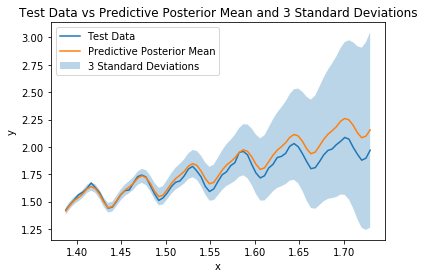

In [228]:
#Generate plot of Test Data vs Predictive Posterior Mean and 3 Standard Deviations for question 2.
Question2()